HDF5 DAS File created successfully: '../data/synthetic_das_record.h5'
Loaded DAS Matrix Shape: (500, 2000) (Channels x Time Samples)
Metadata: Sampling Rate = 200.0 Hz, Channel Spacing = 2.0 m


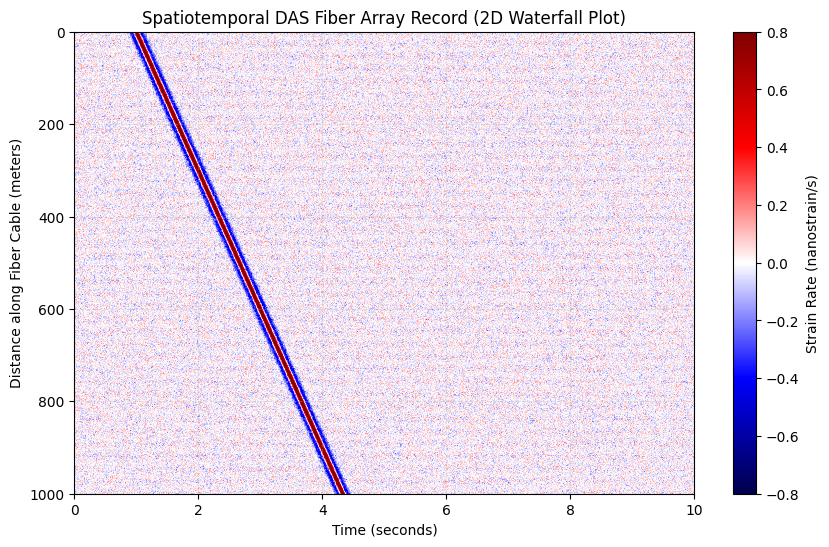

DAS Waterfall visualization successfully saved to '../images/step4_das_waterfall.png'


In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

#1 Generating & writing Synthetic DAS Array Data to an HDF5 File
os.makedirs('../data', exist_ok=True)
os.makedirs('../images', exist_ok=True)
h5_filepath = '../data/synthetic_das_record.h5'

num_channels = 500      # 500 virtual sensors along a 1 km fiber (2m spacing)
num_time_samples = 2000  # 10 seconds of recording at 200 Hz
sampling_rate = 200.0   # Hz
wave_velocity = 300.0   # Seismic wave speed (m/s)

time_axis = np.linspace(0, num_time_samples / sampling_rate, num_time_samples)
channel_positions = np.arange(num_channels) * 2.0  # Distance in meters

# Constructing a spatiotemporal wave field: A wave traveling across fiber channels
das_data_matrix = np.zeros((num_channels, num_time_samples))
np.random.seed(42)

for ch_idx, distance in enumerate(channel_positions):
    # Calculating travel time delay for wave to reach this specific channel
    time_delay = distance / wave_velocity
    
    # Ricker wavelet-like seismic signal propagating across channels
    t_shifted = time_axis - time_delay - 1.0  # 1s initial delay
    signal = (1 - 2 * (np.pi * 5 * t_shifted)**2) * np.exp(-(np.pi * 5 * t_shifted)**2)
    
    # Adding ambient urban background noise
    noise = np.random.normal(0, 0.15, num_time_samples)
    das_data_matrix[ch_idx, :] = signal + noise

# Writing matrix and metadata to HDF5 binary file
with h5py.File(h5_filepath, 'w') as h5f:
    # Creating main raw data group and dataset
    raw_group = h5f.create_group('raw_data')
    dset = raw_group.create_dataset('strain_rate', data=das_data_matrix, compression="gzip")
    
    # Storing essential metadata attributes
    dset.attrs['sampling_rate_hz'] = sampling_rate
    dset.attrs['channel_spacing_m'] = 2.0
    dset.attrs['units'] = 'nanostrain/s'

print(f"HDF5 DAS File created successfully: '{h5_filepath}'")


#2 Reading & Parse the HDF5 DAS Array File
with h5py.File(h5_filepath, 'r') as h5f:
    # Reading dataset and metadata from HDF5 structure
    das_matrix = h5f['raw_data/strain_rate'][:]
    fs = h5f['raw_data/strain_rate'].attrs['sampling_rate_hz']
    dx = h5f['raw_data/strain_rate'].attrs['channel_spacing_m']
    units = h5f['raw_data/strain_rate'].attrs['units']

print(f"Loaded DAS Matrix Shape: {das_matrix.shape} (Channels x Time Samples)")
print(f"Metadata: Sampling Rate = {fs} Hz, Channel Spacing = {dx} m")


#3 Generating 2D DAS Spatiotemporal Waterfall Plot
plt.figure(figsize=(10, 6))

# Displaying 2D spatiotemporal strain rate matrix
time_extent = [0, num_time_samples / fs]
distance_extent = [0, num_channels * dx]

plt.imshow(
    das_matrix, 
    aspect='auto', 
    cmap='seismic', 
    extent=[time_extent[0], time_extent[1], distance_extent[1], distance_extent[0]],
    vmin=-0.8, vmax=0.8
)

plt.colorbar(label=f'Strain Rate ({units})')
plt.title('Spatiotemporal DAS Fiber Array Record (2D Waterfall Plot)')
plt.xlabel('Time (seconds)')
plt.ylabel('Distance along Fiber Cable (meters)')
plt.grid(True, linestyle='--', alpha=0.3)

# Saving the plot
output_plot_path = '../images/step4_das_waterfall.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"DAS Waterfall visualization successfully saved to '{output_plot_path}'")